In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch

import re
import pandas as pd
import numpy as np
import nltk
import pymorphy3
import optuna
import mlflow
import pickle
import implicit
import os
import gc



from implicit.als import AlternatingLeastSquares
from scipy.sparse import coo_matrix, csr_matrix
from optuna.integration.mlflow import MLflowCallback
from mlflow.utils.mlflow_tags import MLFLOW_PARENT_RUN_ID
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from nltk.corpus import stopwords
from mlxtend.plotting import plot_decision_regions
from tqdm import tqdm
from scipy.sparse import csr_matrix, vstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from gensim.utils import simple_preprocess
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import os
from sentencepiece import SentencePieceTrainer, SentencePieceProcessor

import warnings
warnings.simplefilter('ignore', FutureWarning)

from sklearn import set_config
set_config(display='diagram')

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "hr-ai-scout"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

In [4]:
df = pd.read_csv("total_df_10%.csv")
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_salary_from,vacancy_salary_to,vacancy_salary_currency,vacancy_salary_gross,...,resume_education,resume_courses,resume_salary,resume_age,resume_total_experience,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Казанский Авиационный Институт'],NaN,NaN,65.0,19 лет,228.0,Москва,Мужчина,Рассматривает предложения,1
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,"['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...","['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...",NaN,43.0,17 лет 4 месяца,208.0,Москва,Мужчина,Рассматривает предложения,1
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Орский государственный педагогический инстит...,NaN,200 000 ₽ на руки,52.0,30 лет,360.0,Москва,Женщина,NaN,1
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Красноярский государственный университет'],NaN,500 000 ₽ на руки,56.0,29 лет 8 месяцев,356.0,Красноярск,Мужчина,Рассматривает предложения,1
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Белоруский Гос. Университет Информатики и Ра...,"['SAP CIS, SAP XI', 'Школа Логистики МАДИ', 'S...",NaN,48.0,25 лет 1 месяц,301.0,Moscow,Male,NaN,1


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
В первую очередь уберем строки, где пропущены все ключевые значения в резюме:
</div>

In [5]:
t1 = df.shape[0]
df = df.dropna(subset= ["resume_education",
                        "resume_last_experience_description",
                        "resume_last_position",
                        "resume_last_company_experience_period",
                        "resume_total_experience",
                        "resume_experience_months",
                        "resume_location",
                        "resume_specialization",
                        # "resume_gender",
                        # "resume_title"
                       ], how="all")
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строки')

Удалено  84  строки


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Удалим еще те строки, где случился технический сбой в парсинге, где у кандидата общий опыт есть, а последний опыт не указан (и наоборот):
</div>

In [6]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].notna()
        & df["resume_last_experience_description"].isna()
        & df["resume_last_position"].isna())]
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строк')

Удалено  1543  строк


In [7]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].isna()
        & df["resume_last_experience_description"].notna()
        & df["resume_last_position"].notna())]
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строк')

Удалено  0  строк


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Посмотрим на пропуски отдельно по категориальным и числовым признакам.
</div>

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [9]:
df[cat_cols] = df[cat_cols].fillna('NDT')

In [10]:
df.loc[df['resume_experience_months'].isna(), 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

In [11]:
df['resume_age'] = df['resume_age'].fillna(df['resume_age'].mean())
df['resume_experience_months'] = df['resume_experience_months'].fillna(0)

In [12]:
df = df.drop(['vacancy_salary_to', 'vacancy_salary_from',
              'vacancy_salary_currency', 'vacancy_salary_gross'], axis=1)

In [13]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Преобразуем сначала ожидаемые зарплаты
</div>

In [14]:
df['resume_salary_split'] = df['resume_salary'].apply(lambda x: x.split())

df['salary_int'] = df['resume_salary_split'].apply(
    lambda x: int(''.join(part for part in x if re.fullmatch(r'\d+', part)))
              if any(re.fullmatch(r'\d+', part) for part in x)
              else np.nan
)

currency_symbols = ['₽', '$', '€', '₴', '₸', '₼', '₾', 'Br', "so'm"]

rates_rub = {
    "₽": 1.0,
    "$": 80.85,
    "€": 94.14,
    "₴": 1.94,
    "₸": 0.150,
    "₼": 47.8,
    "₾": 33.5,
    "Br": 28.7,
    "so'm": 0.0068
}

df['currency_symbol'] = df['resume_salary_split'].apply(
    lambda x: next((sym for sym in x if sym in currency_symbols), np.nan)
)

df['salary_converted'] = (df['salary_int'] * df['currency_symbol'].map(rates_rub)).fillna(0)

df['resume_salary'] = df['salary_converted']

df = df.drop(['resume_salary_split', 'salary_int', 'currency_symbol', 'salary_converted'], axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим дополнительный столбец с опытом работы в последней компании в месяцах для удобства
</div>

In [15]:
def experience_to_months(experience_text):
    months = 0
    # Опыт в годах
    years_match = re.search(r'(\d+)\s*год', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    years_match = re.search(r'(\d+)\s*лет', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    # Опыт в месяцах
    months_match = re.search(r'(\d+)\s*месяц', experience_text)
    if months_match:
        months += int(months_match.group(1))

    return months if months > 0 else np.nan

In [16]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_period'].apply(experience_to_months)

In [17]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Т.к. в названии компании стоит NDT, можно столбец resume_last_company_experience_months заполнять нулевыми значениями.
</div>

In [18]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_months'].fillna(0)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Ограничим выбросы по зарплате, потому что ровно одно значение по ожидаемой заработоной плате = 999,999,999 (смешно, но нет)

- Ограничим опыт общий и внутри одной компании до 720 месяцев (60 лет, ничего себе уже)

- Уберем возраст > 90, не ждем, что эти кандидаты находятся в поиске вакансии
</div>

In [19]:
df = df[~(df.resume_salary > 1e7)]
df.loc[df['resume_experience_months'] > 720, 'resume_experience_months'] = 720
df.loc[df['resume_last_company_experience_months'] > 720, 'resume_last_company_experience_months'] = 720
df = df[~(df.resume_age > 90)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Также уберем строки, где последний опыт кандидата больше, чем общий

- И где общий опыт кандидата +16 лет больше чем возраст (хоть так)

</div>

In [20]:
df = df[~(df.resume_experience_months < df.resume_last_company_experience_months)]
df = df[~(df.resume_age < (df.resume_experience_months // 12) + 16)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Заменим текущий формат разброса полов в датасете на унифицированный

</div>

In [21]:
gender_map = {
    'Мужчина': 'Мужчина',
    'Male': 'Мужчина',
    'Женщина': 'Женщина',
    'Female': 'Женщина'
}

df['resume_gender'] = df['resume_gender'].apply(lambda x: gender_map[x] if x in gender_map else 'Неизвестно')

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

В этой версии ноутбука полностью отказываемся от табличных признаков, ALS и TF-IDF. Используем только два текстовых поля - vacancy_description и resume_last_experience_description. Из них строим:

- BPE-токенизацию для текстовых DL-бейзлайнов RNN / LSTM
- BERT-эмбеддинги (frozen feature extractor) для основной серии экспериментов

</div>

In [22]:
df['vacancy_description'] = df['vacancy_description'].astype(str)
df['resume_last_experience_description'] = df['resume_last_experience_description'].astype(str)

In [23]:
y = df['target'].copy()
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [24]:
len(train_idx), len(test_idx), y_train.shape, y_test.shape

(260434, 65109, (260434,), (65109,))

In [25]:
def calculate_metrics(df_test: pd.DataFrame) -> pd.DataFrame:
    ndcg_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    vacancy_ids = df_test['vacancy_id'].unique()
    
    for vacancy_id in vacancy_ids:
        mask = df_test['vacancy_id'] == vacancy_id
        y_true = df_test.loc[mask, 'target'].values
        y_score = df_test.loc[mask, 'y_pred_proba'].values
        
        if len(y_true) <= 1:
            continue
        
        y_true_2d = y_true.reshape(1, -1)
        y_score_2d = y_score.reshape(1, -1)
        
        ndcg = ndcg_score(y_true_2d, y_score_2d)
        ndcg_scores.append(ndcg)
        
        y_pred_binary = (y_score >= 0.5).astype(int)
        
        precision = precision_score(y_true, y_pred_binary, zero_division=0)
        recall = recall_score(y_true, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true, y_pred_binary, zero_division=0)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
    
    if ndcg_scores:
        print(f"Средний NDCG: {np.mean(ndcg_scores):.4f}")
        print(f"Средний Precision: {np.mean(precision_scores):.4f}")
        print(f"Средний Recall: {np.mean(recall_scores):.4f}")
        print(f"Средний F1-Score: {np.mean(f1_scores):.4f}")

        return np.mean(ndcg_scores), np.mean(precision_scores), np.mean(recall_scores), np.mean(f1_scores)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Попробуем построить DL-модели только на тексте vacancy_description + resume_last_experience_description:

- TextClassifier (RNN) - рекуррентная сеть на BPE-токенах (sentencepiece) поверх склеенного текста vacancy [SEP] resume
- TextClassifier (LSTM) - то же, но с LSTM
- BERT-эмбеддинги frozen feature extractor от LaBSE-en-ru + лёгкая MLP-голова на парных признаках [v, r, |v-r|, v*r]
- Гибрид: BERT + LSTM на BPE - две параллельные ветки и общая голова

</div>

In [26]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
_torch_lib = os.path.join(os.path.dirname(sys.executable), 'Lib', 'site-packages', 'torch', 'lib')
if os.path.isdir(_torch_lib):
    os.add_dll_directory(_torch_lib)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 13})

device = torch.device('cuda')
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Универсальные функции training_epoch, validation_epoch, train, plot_losses
- Лосс — BCEWithLogitsLoss для бинарной классификации (с pos_weight для борьбы с дисбалансом классов)

</div>

In [27]:
def plot_losses(train_losses, val_losses, train_aucs=None, val_aucs=None):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    if train_aucs is not None and val_aucs is not None:
        axs[1].plot(range(1, len(train_aucs) + 1), train_aucs, label='train')
        axs[1].plot(range(1, len(val_aucs) + 1), val_aucs, label='val')
        axs[1].set_ylabel('roc_auc')
    else:
        axs[1].plot(range(1, len(train_losses) + 1), [np.exp(l) for l in train_losses], label='train')
        axs[1].plot(range(1, len(val_losses) + 1), [np.exp(l) for l in val_losses], label='val')
        axs[1].set_ylabel('perplexity')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [28]:
def training_epoch(model, optimizer, criterion, loader, tqdm_desc, forward_fn):
    model.train()
    train_loss = 0.0
    all_targets, all_probs = [], []

    for batch in tqdm(loader, desc=tqdm_desc, leave=False):
        optimizer.zero_grad()
        logits, targets = forward_fn(model, batch)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * targets.size(0)
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())

    train_loss /= len(loader.dataset)
    auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
    return train_loss, auc


@torch.no_grad()
def validation_epoch(model, criterion, loader, tqdm_desc, forward_fn):
    model.eval()
    val_loss = 0.0
    all_targets, all_probs = [], []

    for batch in tqdm(loader, desc=tqdm_desc, leave=False):
        logits, targets = forward_fn(model, batch)
        loss = criterion(logits, targets)
        val_loss += loss.item() * targets.size(0)
        all_targets.append(targets.cpu().numpy())
        all_probs.append(torch.sigmoid(logits).cpu().numpy())

    val_loss /= len(loader.dataset)
    auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
    return val_loss, auc


def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, forward_fn, scheduler=None, verbose=True):
    train_losses, val_losses, train_aucs, val_aucs = [], [], [], []

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_auc = training_epoch(model, optimizer, criterion, train_loader,
                                         f'Train {epoch}/{num_epochs}', forward_fn)
        v_loss, v_auc = validation_epoch(model, criterion, val_loader,
                                         f'Val   {epoch}/{num_epochs}', forward_fn)
        if scheduler is not None:
            scheduler.step()

        train_losses.append(tr_loss); val_losses.append(v_loss)
        train_aucs.append(tr_auc); val_aucs.append(v_auc)
        if verbose:
            plot_losses(train_losses, val_losses, train_aucs, val_aucs)
            print(f'Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={v_loss:.4f} train_auc={tr_auc:.4f} val_auc={v_auc:.4f}')

    return train_losses, val_losses, train_aucs, val_aucs


@torch.no_grad()
def predict_proba(model, loader, forward_fn):
    model.eval()
    probs = []
    for batch in loader:
        logits, _ = forward_fn(model, batch)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

In [29]:
BATCH_SIZE = 512

pos_weight_value = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)


def run_dl_experiment(run_name, model, train_loader, test_loader, forward_fn,
                      num_epochs=20, lr=1e-3, weight_decay=0.0, hyperparams=None,
                      verbose=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_losses, val_losses, train_aucs, val_aucs = train_model(
        model, optimizer, criterion, train_loader, test_loader,
        num_epochs=num_epochs, forward_fn=forward_fn, verbose=verbose
    )

    y_pred_proba_test = predict_proba(model, test_loader, forward_fn)
    df_test_dl = df.loc[test_idx].copy()
    df_test_dl['y_pred_proba'] = y_pred_proba_test

    ndcg, precision, recall, f1 = calculate_metrics(df_test_dl)
    metrics = {'NDCG': ndcg, 'Precision': precision, 'Recall': recall, 'F1': f1,
               'val_auc_last': val_aucs[-1], 'val_loss_last': val_losses[-1]}

    try:
        experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
    except Exception:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=run_name, experiment_id=experiment_id):
        mlflow.log_metrics(metrics)
        if hyperparams is not None:
            mlflow.log_params(hyperparams)
        mlflow.log_param('num_epochs', num_epochs)
        mlflow.log_param('lr', lr)
        mlflow.log_param('weight_decay', weight_decay)
        mlflow.log_param('batch_size', BATCH_SIZE)

    return metrics, model

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Берём тексты vacancy_description + SEP + resume_last_experience_description
- Токенизация - BPE через sentencepiece

</div>

In [30]:
df['_text_for_dl'] = (
    df['vacancy_description'].fillna('').astype(str)
    + ' [SEP] '
    + df['resume_last_experience_description'].fillna('').astype(str)
)

CORPUS_FILE = 'dl_text_corpus.txt'
SP_PREFIX = 'dl_bpe'
VOCAB_SIZE = 4000

if not os.path.isfile(CORPUS_FILE):
    with open(CORPUS_FILE, 'w', encoding='utf-8') as f:
        for t in df['_text_for_dl'].tolist():
            f.write(t.replace('\n', ' ') + '\n')

if not os.path.isfile(SP_PREFIX + '.model'):
    SentencePieceTrainer.train(
        input=CORPUS_FILE,
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        model_prefix=SP_PREFIX,
        normalization_rule_name='identity',
        character_coverage=1.0,
    )

sp_model = SentencePieceProcessor(model_file=SP_PREFIX + '.model')

In [31]:
class ResumeVacancyTextDataset(Dataset):

    def __init__(self, texts, targets, sp_model, max_length=128):
        self.sp_model = sp_model
        self.max_length = max_length
        self.indices = self.sp_model.encode(list(texts))
        self.targets = np.asarray(targets, dtype=np.float32)
        self.pad_id = self.sp_model.pad_id()
        self.bos_id = self.sp_model.bos_id()
        self.eos_id = self.sp_model.eos_id()
        self.vocab_size = self.sp_model.vocab_size()
        if self.pad_id < 0:
            self.pad_id = 0

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        enc = [self.bos_id] + self.indices[item] + [self.eos_id]
        length = min(len(enc), self.max_length)
        enc = enc[:self.max_length]
        pad_len = self.max_length - len(enc)
        enc = enc + [self.pad_id] * pad_len
        indices = torch.tensor(enc, dtype=torch.long)
        return indices, length, torch.tensor(self.targets[item], dtype=torch.float32)


train_text_dataset = ResumeVacancyTextDataset(
    df.loc[train_idx, '_text_for_dl'].tolist(),
    y_train.values,
    sp_model,
    max_length=128,
)
test_text_dataset = ResumeVacancyTextDataset(
    df.loc[test_idx, '_text_for_dl'].tolist(),
    y_test.values,
    sp_model,
    max_length=128,
)

train_text_loader = DataLoader(train_text_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_text_loader = DataLoader(test_text_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [32]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=128,
                 rnn_type=nn.RNN, rnn_layers=1, dropout=0.0, pad_id=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_id)
        self.rnn = rnn_type(embed_size, hidden_size,
                            num_layers=rnn_layers, batch_first=True,
                            dropout=dropout if rnn_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, indices, lengths):
        max_len = lengths.max().item()
        indices = indices[:, :max_len]

        emb = self.embedding(indices)
        out, _ = self.rnn(emb)

        idx = (lengths - 1).clamp(min=0).to(out.device)
        last_hidden = out[torch.arange(out.size(0), device=out.device), idx]
        last_hidden = self.dropout(last_hidden)
        logits = self.linear(last_hidden)
        return logits


def text_forward(model, batch):
    indices, lengths, y = batch
    indices = indices.to(device)
    lengths = lengths.to(device)
    y = y.to(device)
    logits = model(indices, lengths).squeeze(-1)
    return logits, y

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сначала обучим обычную RNN

</div>

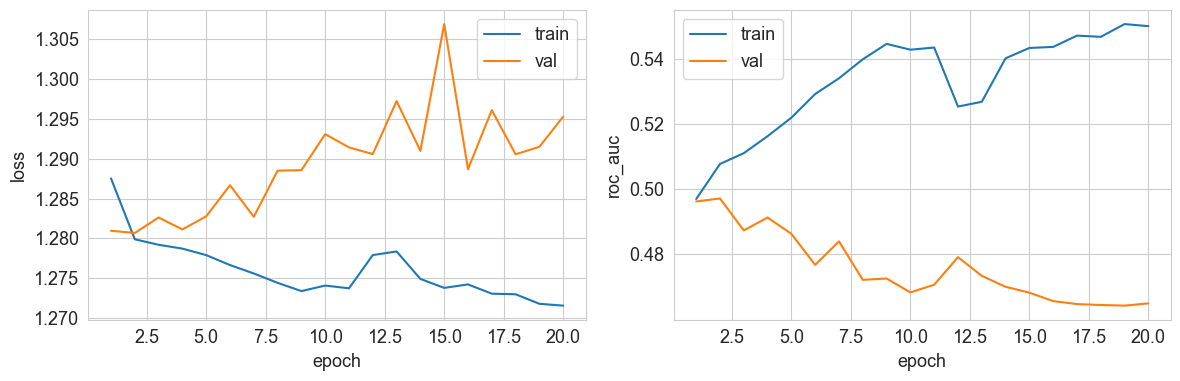

Epoch 20: train_loss=1.2715 val_loss=1.2953 train_auc=0.5499 val_auc=0.4650
Средний NDCG: 0.3322
Средний Precision: 0.0313
Средний Recall: 0.3442
Средний F1-Score: 0.0564
🏃 View run RNN_text at: http://127.0.0.1:5000/#/experiments/1/runs/2507c91d3ea04d728ee3f9b8d3b8ed1b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [33]:
torch.manual_seed(RANDOM_STATE)
rnn_model = TextClassifier(
    vocab_size=sp_model.vocab_size(),
    embed_size=128,
    hidden_size=128,
    rnn_type=nn.RNN,
    rnn_layers=1,
    dropout=0.2,
    pad_id=train_text_dataset.pad_id,
)

metrics_rnn, _ = run_dl_experiment(
    run_name='RNN_text',
    model=rnn_model,
    train_loader=train_text_loader,
    test_loader=test_text_loader,
    forward_fn=text_forward,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    hyperparams={'embed_size': 128, 'hidden_size': 128, 'rnn_type': 'RNN',
                 'rnn_layers': 1, 'dropout': 0.2, 'max_length': 128, 'vocab_size': VOCAB_SIZE},
)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь LSTM

</div>

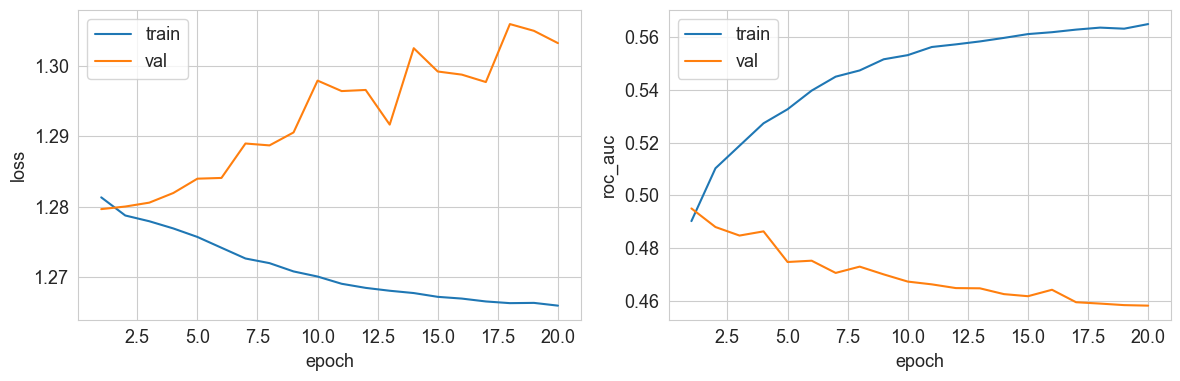

Epoch 20: train_loss=1.2659 val_loss=1.3033 train_auc=0.5649 val_auc=0.4582
Средний NDCG: 0.3320
Средний Precision: 0.0373
Средний Recall: 0.4065
Средний F1-Score: 0.0671
🏃 View run LSTM_text at: http://127.0.0.1:5000/#/experiments/1/runs/67a28ce8f1ad4ef1aa7c2b920b3655d5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [34]:
torch.manual_seed(RANDOM_STATE)
lstm_model = TextClassifier(
    vocab_size=sp_model.vocab_size(),
    embed_size=128,
    hidden_size=128,
    rnn_type=nn.LSTM,
    rnn_layers=1,
    dropout=0.2,
    pad_id=train_text_dataset.pad_id,
)

metrics_lstm, _ = run_dl_experiment(
    run_name='LSTM_text',
    model=lstm_model,
    train_loader=train_text_loader,
    test_loader=test_text_loader,
    forward_fn=text_forward,
    num_epochs=20,
    lr=0.001,
    weight_decay=1e-5,
    hyperparams={'embed_size': 128, 'hidden_size': 128, 'rnn_type': 'LSTM',
                 'rnn_layers': 1, 'dropout': 0.2, 'max_length': 128, 'vocab_size': VOCAB_SIZE},
)

BERT - MLP

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Используем предобученные BERT-модели как frozen feature extractor, считаем эмбеддинги для текстов вакансии и резюме один раз, кэшируем на диск, поверх обучаем лёгкий MLP на парных признаках [v, r, |v-r|, v*r]

Делаем явно через AutoTokenizer + AutoModel - токенизация, forward, mean pooling по attention_mask, L2-нормализация

Победившая модель - cointegrated/LaBSE-en-ru (модель заточена под semantic similarity, обучалась контрастивно, хорошо работает на смешанном ru/en), остальные модели, которые сравнивали cointegrated/rubert-tiny2, sergeyzh/rubert-tiny-turbo, DeepPavlov/rubert-base-cased, intfloat/multilingual-e5-base, ai-forever/sbert_large_nlu_ru

 Оставляем только её и пробуем 2 варианта текста резюме:

- basic - только resume_last_experience_description
- enriched - last_position + specialization + skills + last_experience_description



</div>

In [35]:
BERT_CACHE_DIR = 'bert_cache'
os.makedirs(BERT_CACHE_DIR, exist_ok=True)

BERT_MODEL_NAME = 'cointegrated/LaBSE-en-ru'
BERT_MAX_LENGTH = 256
BERT_E5_PREFIX = False


def _slug(model_name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9]+', '_', model_name).strip('_')


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


@torch.no_grad()
def embed_texts(model_name: str, texts: list, batch_size: int = 32,
                max_length: int = 256, e5_prefix: bool = False) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    if e5_prefix:
        texts = [f'passage: {t}' for t in texts]

    all_emb = []
    for start in tqdm(range(0, len(texts), batch_size), desc=f'embed {model_name}', leave=False):
        batch = texts[start:start + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(device)
        out = model(**enc)
        emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu().numpy().astype(np.float32))

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return np.concatenate(all_emb, axis=0)


def build_resume_text_basic(row) -> str:
    return str(row.get('resume_last_experience_description') or '')


def build_resume_text_enriched(row) -> str:
    parts = [
        str(row.get('resume_last_position') or ''),
        str(row.get('resume_specialization') or ''),
        str(row.get('resume_skills') or ''),
        str(row.get('resume_last_experience_description') or ''),
    ]
    return '. '.join(p.strip() for p in parts if p and p.strip())


def compute_or_load_embeddings(model_name: str, max_length: int, e5_prefix: bool,
                               resume_text_builder, variant_tag: str,
                               batch_size: int = 32):
    slug = _slug(model_name)
    vac_path = os.path.join(BERT_CACHE_DIR, f'{slug}_vac.npz')
    res_path = os.path.join(BERT_CACHE_DIR, f'{slug}_res_{variant_tag}.npz')

    unique_vac = df[['vacancy_id', 'vacancy_description']].drop_duplicates('vacancy_id')

    res_cols = ['resume_id', 'resume_last_experience_description',
                'resume_last_position', 'resume_specialization', 'resume_skills']
    res_cols = [c for c in res_cols if c in df.columns]
    unique_res = df[res_cols].drop_duplicates('resume_id')

    if os.path.isfile(vac_path):
        vac_npz = np.load(vac_path, allow_pickle=True)
        vac_ids, vac_emb = vac_npz['ids'], vac_npz['emb']
    else:
        vac_emb = embed_texts(model_name, unique_vac['vacancy_description'].tolist(),
                              batch_size=batch_size, max_length=max_length, e5_prefix=e5_prefix)
        vac_ids = unique_vac['vacancy_id'].values
        np.savez(vac_path, ids=vac_ids, emb=vac_emb)

    if os.path.isfile(res_path):
        res_npz = np.load(res_path, allow_pickle=True)
        res_ids, res_emb = res_npz['ids'], res_npz['emb']
    else:
        res_texts = unique_res.apply(resume_text_builder, axis=1).tolist()
        res_emb = embed_texts(model_name, res_texts,
                              batch_size=batch_size, max_length=max_length, e5_prefix=e5_prefix)
        res_ids = unique_res['resume_id'].values
        np.savez(res_path, ids=res_ids, emb=res_emb)

    vac_pos = {int(v): i for i, v in enumerate(vac_ids)}
    res_pos = {int(r): i for i, r in enumerate(res_ids)}
    return vac_emb, vac_pos, res_emb, res_pos

In [36]:
class PairEmbDataset(Dataset):

    def __init__(self, vacancy_ids, resume_ids, targets,
                 vac_emb, vac_pos, res_emb, res_pos):
        self.vac_idx = np.asarray([vac_pos[int(v)] for v in vacancy_ids], dtype=np.int64)
        self.res_idx = np.asarray([res_pos[int(r)] for r in resume_ids], dtype=np.int64)
        self.targets = np.asarray(targets, dtype=np.float32)
        self.vac_emb = vac_emb
        self.res_emb = res_emb
        self.dim = vac_emb.shape[1]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, item):
        v = self.vac_emb[self.vac_idx[item]]
        r = self.res_emb[self.res_idx[item]]
        feat = np.concatenate([v, r, np.abs(v - r), v * r], axis=0).astype(np.float32)
        return torch.from_numpy(feat), torch.tensor(self.targets[item], dtype=torch.float32)


class PairMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x)


def pair_forward(model, batch):
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    logits = model(x).squeeze(-1)
    return logits, y

In [37]:
def run_bert_mlp_pipeline(model_name: str, max_length: int, e5_prefix: bool,
                          resume_text_builder, variant_tag: str,
                          batch_size_emb: int = 32, mlp_hidden: int = 256,
                          mlp_dropout: float = 0.3, num_epochs: int = 20,
                          lr: float = 0.001, weight_decay: float = 1e-5):
    slug = _slug(model_name)

    vac_emb, vac_pos, res_emb, res_pos = compute_or_load_embeddings(
        model_name=model_name, max_length=max_length, e5_prefix=e5_prefix,
        resume_text_builder=resume_text_builder, variant_tag=variant_tag,
        batch_size=batch_size_emb,
    )
    dim = vac_emb.shape[1]

    train_ds = PairEmbDataset(
        df.loc[train_idx, 'vacancy_id'].values,
        df.loc[train_idx, 'resume_id'].values,
        y_train.values,
        vac_emb, vac_pos, res_emb, res_pos,
    )
    test_ds = PairEmbDataset(
        df.loc[test_idx, 'vacancy_id'].values,
        df.loc[test_idx, 'resume_id'].values,
        y_test.values,
        vac_emb, vac_pos, res_emb, res_pos,
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(RANDOM_STATE)
    model = PairMLP(input_dim=4 * dim, hidden=mlp_hidden, dropout=mlp_dropout)

    metrics, model = run_dl_experiment(
        run_name=f'BERT_{slug}_{variant_tag}_mlp',
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        forward_fn=pair_forward,
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
        hyperparams={'bert_model': model_name, 'dim': dim, 'mlp_hidden': mlp_hidden,
                     'mlp_dropout': mlp_dropout, 'max_length': max_length,
                     'e5_prefix': e5_prefix, 'resume_variant': variant_tag},
        verbose=False,
    )
    return metrics, model, (vac_emb, vac_pos, res_emb, res_pos)


bert_results = {}
bert_models_state = {}
bert_embeddings_by_variant = {}

VARIANTS = [
    ('basic',    build_resume_text_basic),
    ('enriched', build_resume_text_enriched),
]

for variant_tag, builder in VARIANTS:
    metrics, mlp_model, embs = run_bert_mlp_pipeline(
        model_name=BERT_MODEL_NAME,
        max_length=BERT_MAX_LENGTH,
        e5_prefix=BERT_E5_PREFIX,
        resume_text_builder=builder,
        variant_tag=variant_tag,
        batch_size_emb=32,
        mlp_hidden=256,
        mlp_dropout=0.3,
        num_epochs=20,
        lr=0.001,
        weight_decay=1e-5,
    )
    bert_results[variant_tag] = metrics
    bert_models_state[variant_tag] = {k: v.detach().cpu() for k, v in mlp_model.state_dict().items()}
    bert_embeddings_by_variant[variant_tag] = embs

bert_results

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/LaBSE-en-ru
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embed cointegrated/LaBSE-en-ru:   0%|          | 0/107 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/LaBSE-en-ru
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Val   19/20:   0%|          | 0/128 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/509 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/128 [00:00<?, ?it/s]

Средний NDCG: 0.7535
Средний Precision: 0.4992
Средний Recall: 0.7599
Средний F1-Score: 0.5758
🏃 View run BERT_cointegrated_LaBSE_en_ru_enriched_mlp at: http://127.0.0.1:5000/#/experiments/1/runs/1237e69f7a2849c5b3e34b1e9a0de5f6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


{'basic': {'NDCG': np.float64(0.7513972572295454),
  'Precision': np.float64(0.5869519060190812),
  'Recall': np.float64(0.7274616211987874),
  'F1': np.float64(0.6274845603534369),
  'val_auc_last': 0.9856471162404943,
  'val_loss_last': 0.3120260207313575},
 'enriched': {'NDCG': np.float64(0.7534959495562706),
  'Precision': np.float64(0.49920526167226076),
  'Recall': np.float64(0.7599344871418794),
  'F1': np.float64(0.5757802586387819),
  'val_auc_last': 0.9876289835467147,
  'val_loss_last': 0.2694299174579255}}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Совмещаем BERT-эмбеддинги и обучаемый LSTM на BPE-токенах в одной модели:

- BERT-ветка: парные фичи [v, r, |v-r|, v*r] → Linear - ReLU
- LSTM-ветка: BPE-токены → Embedding - LSTM - последний скрытый по реальной длине
- Ветки конкатенируются и проходят через общую голову Linear - ReLU - Linear

BERT здесь не дообучается, только feature extractor. Дообучаются BPE-эмбеддинги, LSTM и MLP-головы. Используем эмбеддинги от enriched варианта.

</div>

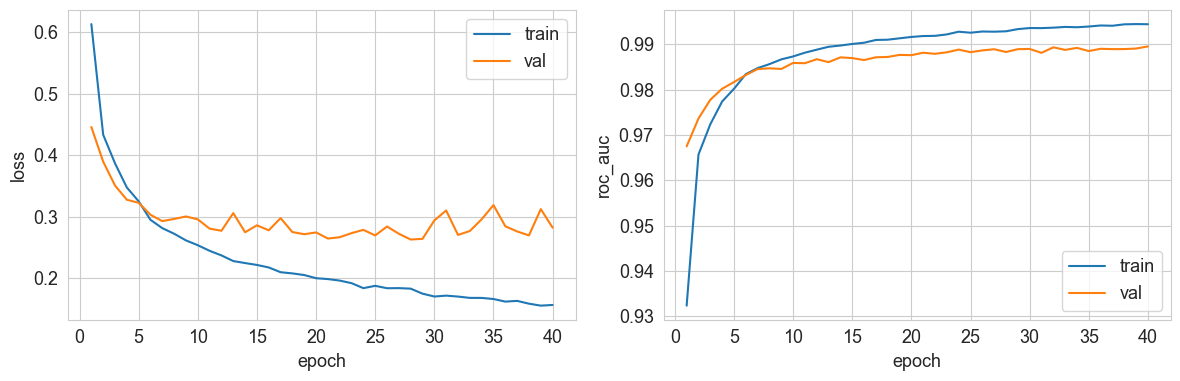

Epoch 40: train_loss=0.1565 val_loss=0.2821 train_auc=0.9944 val_auc=0.9895
Средний NDCG: 0.7557
Средний Precision: 0.6190
Средний Recall: 0.7368
Средний F1-Score: 0.6521
🏃 View run BERT_cointegrated_LaBSE_en_ru_enriched_lstm_hybrid at: http://127.0.0.1:5000/#/experiments/1/runs/84c826930fb644c4aa014217fb12bcfb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [38]:
class HybridBertLSTMDataset(Dataset):

    def __init__(self, text_dataset: ResumeVacancyTextDataset,
                 vacancy_ids, resume_ids,
                 vac_emb, vac_pos, res_emb, res_pos):
        assert len(text_dataset) == len(vacancy_ids) == len(resume_ids)
        self.text_dataset = text_dataset
        self.vac_idx = np.asarray([vac_pos[int(v)] for v in vacancy_ids], dtype=np.int64)
        self.res_idx = np.asarray([res_pos[int(r)] for r in resume_ids], dtype=np.int64)
        self.vac_emb = vac_emb
        self.res_emb = res_emb
        self.dim = vac_emb.shape[1]

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, item):
        indices, length, target = self.text_dataset[item]
        v = self.vac_emb[self.vac_idx[item]]
        r = self.res_emb[self.res_idx[item]]
        bert_feat = np.concatenate([v, r, np.abs(v - r), v * r], axis=0).astype(np.float32)
        return indices, length, torch.from_numpy(bert_feat), target

class HybridBertLSTM(nn.Module):
    def __init__(self, vocab_size, bert_pair_dim, embed_size=128, lstm_hidden=128,
                 bert_hidden=128, head_hidden=64, dropout=0.3, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_size, lstm_hidden, num_layers=1, batch_first=True)

        self.bert_branch = nn.Sequential(
            nn.Linear(bert_pair_dim, bert_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden + bert_hidden, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )

    def forward(self, indices, lengths, bert_feat):
        max_len = lengths.max().item()
        indices = indices[:, :max_len]
        emb = self.embedding(indices)
        out, _ = self.lstm(emb)

        idx = (lengths - 1).clamp(min=0).to(out.device)
        text_repr = out[torch.arange(out.size(0), device=out.device), idx]

        bert_repr = self.bert_branch(bert_feat)
        joint = torch.cat([text_repr, bert_repr], dim=-1)
        return self.head(joint)


def hybrid_bert_lstm_forward(model, batch):
    indices, lengths, bert_feat, y = batch
    indices = indices.to(device)
    lengths = lengths.to(device)
    bert_feat = bert_feat.to(device)
    y = y.to(device)
    logits = model(indices, lengths, bert_feat).squeeze(-1)
    return logits, y


vac_emb, vac_pos, res_emb, res_pos = bert_embeddings_by_variant['enriched']
BERT_DIM = vac_emb.shape[1]

train_hybrid_ds = HybridBertLSTMDataset(
    train_text_dataset,
    df.loc[train_idx, 'vacancy_id'].values,
    df.loc[train_idx, 'resume_id'].values,
    vac_emb, vac_pos, res_emb, res_pos,
)
test_hybrid_ds = HybridBertLSTMDataset(
    test_text_dataset,
    df.loc[test_idx, 'vacancy_id'].values,
    df.loc[test_idx, 'resume_id'].values,
    vac_emb, vac_pos, res_emb, res_pos,
)
train_hybrid_loader = DataLoader(train_hybrid_ds, batch_size=BATCH_SIZE, shuffle=True)
test_hybrid_loader = DataLoader(test_hybrid_ds, batch_size=BATCH_SIZE, shuffle=False)

torch.manual_seed(RANDOM_STATE)
hybrid_model = HybridBertLSTM(
    vocab_size=sp_model.vocab_size(),
    bert_pair_dim=4 * BERT_DIM,
    embed_size=128,
    lstm_hidden=128,
    bert_hidden=128,
    head_hidden=64,
    dropout=0.3,
    pad_id=train_text_dataset.pad_id,
)

metrics_hybrid_bert_lstm, hybrid_model = run_dl_experiment(
    run_name=f'BERT_{_slug(BERT_MODEL_NAME)}_enriched_lstm_hybrid',
    model=hybrid_model,
    train_loader=train_hybrid_loader,
    test_loader=test_hybrid_loader,
    forward_fn=hybrid_bert_lstm_forward,
    num_epochs=40,
    lr=0.001,
    weight_decay=0.00001,
    hyperparams={
        'bert_model': BERT_MODEL_NAME, 'bert_dim': BERT_DIM,
        'embed_size': 128, 'lstm_hidden': 128, 'bert_hidden': 128,
        'head_hidden': 64, 'dropout': 0.3, 'resume_variant': 'enriched',
    },
)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Подберём гиперпараметры HybridBertLSTM через Optuna - embed_size, lstm_hidden, bert_hidden, head_hidden, dropout, lr, weight_decay. В trial'ах обучаемся на меньшем числе эпох, потом дообучаем лучшую конфигурацию полным числом эпох.

</div>

In [40]:
def objective_hybrid_bert_lstm(trial: optuna.Trial) -> float:
    embed_size  = trial.suggest_categorical('embed_size',  [64, 128, 256])
    lstm_hidden = trial.suggest_categorical('lstm_hidden', [64, 128, 256])
    bert_hidden = trial.suggest_categorical('bert_hidden', [64, 128, 256])
    head_hidden = trial.suggest_categorical('head_hidden', [32, 64, 128])
    dropout     = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)
    lr          = trial.suggest_float('lr', 0.0001, 0.005, log=True)
    weight_decay = trial.suggest_float('weight_decay', 0.000001, 0.001, log=True)

    torch.manual_seed(RANDOM_STATE)
    model = HybridBertLSTM(
        vocab_size=sp_model.vocab_size(),
        bert_pair_dim=4 * BERT_DIM,
        embed_size=embed_size,
        lstm_hidden=lstm_hidden,
        bert_hidden=bert_hidden,
        head_hidden=head_hidden,
        dropout=dropout,
        pad_id=train_text_dataset.pad_id,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_model(model, optimizer, criterion, train_hybrid_loader, test_hybrid_loader,
                num_epochs=20, forward_fn=hybrid_bert_lstm_forward, verbose=False)

    y_pred_proba_test = predict_proba(model, test_hybrid_loader, hybrid_bert_lstm_forward)
    df_test_dl = df.loc[test_idx].copy()
    df_test_dl['y_pred_proba'] = y_pred_proba_test
    ndcg, _, _, _ = calculate_metrics(df_test_dl)
    return ndcg


try:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
except Exception:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

RUN_NAME_OPTUNA_HYBRID = 'HybridBertLSTM_optuna'
with mlflow.start_run(run_name=RUN_NAME_OPTUNA_HYBRID, experiment_id=experiment_id) as run:
    run_id_hybrid = run.info.run_id

STUDY_DB_NAME = "sqlite:///local.study.db"
STUDY_NAME_HYBRID = "HybridBertLSTM_optuna"

mlflc_hybrid = MLflowCallback(
    tracking_uri=f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}',
    metric_name='NDCG',
    create_experiment=False,
    mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id_hybrid}},
)

study_hybrid = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name=STUDY_NAME_HYBRID,
    storage=STUDY_DB_NAME,
    load_if_exists=True,
)
study_hybrid.optimize(objective_hybrid_bert_lstm, n_trials=15, callbacks=[mlflc_hybrid])

best_params_hybrid = study_hybrid.best_params
study_hybrid.best_value, best_params_hybrid

C:\Users\Puppalupa\AppData\Local\Temp\ipykernel_6608\1706393605.py:47: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflc_hybrid = MLflowCallback(
[I 2026-05-04 20:06:22,388] Using an existing study with name 'HybridBertLSTM_optuna' instead of creating a new one.


🏃 View run HybridBertLSTM_optuna at: http://127.0.0.1:5000/#/experiments/1/runs/89518f9220804396b8d257e0b97b23ce
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/509 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/128 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/509 [00:00<?, ?it/s]

...

Train 20/20:   0%|          | 0/509 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/128 [00:00<?, ?it/s]

[I 2026-05-04 21:11:02,902] Trial 17 finished with value: 0.743901236777629 and parameters: {'embed_size': 64, 'lstm_hidden': 128, 'bert_hidden': 64, 'head_hidden': 64, 'dropout': 0.4, 'lr': 0.0009040175022679674, 'weight_decay': 6.869855312166461e-06}. Best is trial 12 with value: 0.757322176043087.


Средний NDCG: 0.7439
Средний Precision: 0.5090
Средний Recall: 0.7533
Средний F1-Score: 0.5780
🏃 View run 17 at: http://127.0.0.1:5000/#/experiments/1/runs/3865d9aab1c14335aea81d9931d22023
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


(0.757322176043087,
 {'embed_size': 64,
  'lstm_hidden': 128,
  'bert_hidden': 256,
  'head_hidden': 64,
  'dropout': 0.2,
  'lr': 0.0015389525614566042,
  'weight_decay': 5.782090057004767e-06})

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Финальный прогон лучшей конфигурации на большем числе эпох.

</div>

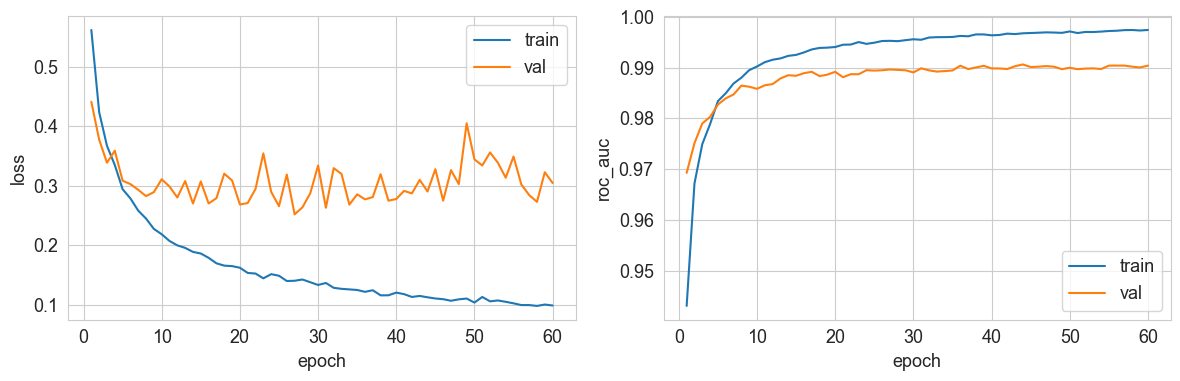

Epoch 60: train_loss=0.0991 val_loss=0.3047 train_auc=0.9974 val_auc=0.9904
Средний NDCG: 0.7592
Средний Precision: 0.6291
Средний Recall: 0.7370
Средний F1-Score: 0.6598
🏃 View run BERT_cointegrated_LaBSE_en_ru_enriched_lstm_hybrid_optuna at: http://127.0.0.1:5000/#/experiments/1/runs/f616b8a90bdd4e9cac2e65ed951cf3a4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [41]:
torch.manual_seed(RANDOM_STATE)
best_hybrid_model = HybridBertLSTM(
    vocab_size=sp_model.vocab_size(),
    bert_pair_dim=4 * BERT_DIM,
    embed_size=best_params_hybrid['embed_size'],
    lstm_hidden=best_params_hybrid['lstm_hidden'],
    bert_hidden=best_params_hybrid['bert_hidden'],
    head_hidden=best_params_hybrid['head_hidden'],
    dropout=best_params_hybrid['dropout'],
    pad_id=train_text_dataset.pad_id,
)

metrics_hybrid_bert_lstm_optuna, best_hybrid_model = run_dl_experiment(
    run_name=f'BERT_{_slug(BERT_MODEL_NAME)}_enriched_lstm_hybrid_optuna',
    model=best_hybrid_model,
    train_loader=train_hybrid_loader,
    test_loader=test_hybrid_loader,
    forward_fn=hybrid_bert_lstm_forward,
    num_epochs=60,
    lr=best_params_hybrid['lr'],
    weight_decay=best_params_hybrid['weight_decay'],
    hyperparams={
        'bert_model': BERT_MODEL_NAME, 'bert_dim': BERT_DIM,
        'resume_variant': 'enriched',
        **best_params_hybrid,
    },
)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сравним модели

</div>

In [42]:
ndcg_lr,             precision_lr,             recall_lr,             f1_lr             = 0.751483, 0.638633, 0.598481, 0.602124
ndcg_catboost_als,   precision_catboost_als,   recall_catboost_als,   f1_catboost_als   = 0.779915, 0.674173, 0.752533, 0.695656

In [43]:
rows = [
    ('LogisticRegression', ndcg_lr,           precision_lr,           recall_lr,           f1_lr),
    ('CatBoost + ALS',     ndcg_catboost_als, precision_catboost_als, recall_catboost_als, f1_catboost_als),
    ('RNN (BPE)',          metrics_rnn['NDCG'],  metrics_rnn['Precision'],  metrics_rnn['Recall'],  metrics_rnn['F1']),
    ('LSTM (BPE)',         metrics_lstm['NDCG'], metrics_lstm['Precision'], metrics_lstm['Recall'], metrics_lstm['F1']),
]

for variant_tag, m in bert_results.items():
    rows.append((f'BERT (LaBSE) + MLP / {variant_tag}',
                 m['NDCG'], m['Precision'], m['Recall'], m['F1']))

m = metrics_hybrid_bert_lstm
rows.append(('BERT (LaBSE) + LSTM hybrid', m['NDCG'], m['Precision'], m['Recall'], m['F1']))

m = metrics_hybrid_bert_lstm_optuna
rows.append(('BERT (LaBSE) + LSTM hybrid (optuna)', m['NDCG'], m['Precision'], m['Recall'], m['F1']))

models_comparison = pd.DataFrame(rows, columns=['Model', 'NDCG', 'Precision', 'Recall', 'F1'])
models_comparison = models_comparison.sort_values('NDCG', ascending=False).reset_index(drop=True)
models_comparison

,Model,NDCG,Precision,Recall,F1
0,CatBoost + ALS,0.779915,0.674173,0.752533,0.695656
1,BERT (LaBSE) + LSTM hybrid (optuna),0.759195,0.629093,0.737020,0.659783
2,BERT (LaBSE) + LSTM hybrid,0.755728,0.619045,0.736765,0.652082
3,BERT (LaBSE) + MLP / enriched,0.753496,0.499205,0.759934,0.575780
4,LogisticRegression,0.751483,0.638633,0.598481,0.602124
5,BERT (LaBSE) + MLP / basic,0.751397,0.586952,0.727462,0.627485
6,RNN (BPE),0.332155,0.031338,0.344211,0.056395
7,LSTM (BPE),0.332013,0.037290,0.406498,0.067086


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Лучше всех себя показала BERT (LaBSE) + LSTM hybrid (optuna) среди DL моделей, однако она все еще уступает CatBoost (или LightGBM) + ALS

</div>

In [44]:
best_variant = max(bert_results.items(), key=lambda kv: kv[1]['NDCG'])[0]
torch.save(
    {
        'bert_model': BERT_MODEL_NAME,
        'resume_variant': best_variant,
        'state_dict': bert_models_state[best_variant],
        'metrics': bert_results[best_variant],
    },
    'best_bert_mlp.pt',
)

if metrics_hybrid_bert_lstm_optuna['NDCG'] >= metrics_hybrid_bert_lstm['NDCG']:
    hybrid_to_save = best_hybrid_model
    hybrid_metrics_to_save = metrics_hybrid_bert_lstm_optuna
    hybrid_params_to_save = best_params_hybrid
else:
    hybrid_to_save = hybrid_model
    hybrid_metrics_to_save = metrics_hybrid_bert_lstm
    hybrid_params_to_save = {
        'embed_size': 128, 'lstm_hidden': 128, 'bert_hidden': 128,
        'head_hidden': 64, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 1e-5,
    }

torch.save(
    {
        'bert_model': BERT_MODEL_NAME,
        'state_dict': hybrid_to_save.state_dict(),
        'metrics': hybrid_metrics_to_save,
        'params': hybrid_params_to_save,
    },
    'best_bert_lstm_hybrid.pt',
)